In [1]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import re 
# get utils for thresholds
from src import util_analysis 

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


## Load participant data and meta files 

In [2]:
## Get all participant data into one df for analysis
def get_part_df(fname):
    part_df = pd.read_csv(fname)
    part_df = part_df[part_df.trial_type == 'dictionary-text'].reset_index(drop=True)
    part_df.trial_num = part_df.trial_num.astype(float).astype('int')
    # part_df['participant'] = fname.stem
    return part_df

def unpack_loc_tuple(loc_tup):
    if isinstance(loc_tup[0], tuple):
        n_dist = 2 
        loc_tup = loc_tup[0]
    else:
        n_dist = 1
    azim, elev = loc_tup 
    azim = abs(azim)
    return azim, elev, n_dist


def get_manifest_df(fname):
    manifest = pd.read_pickle(fname)
    manifest_df = pd.concat([pd.DataFrame(val.values()) for val in manifest.values()]).reset_index(drop=True)
    manifest_df['trial_num'] = manifest_df.index
    # unpack locations to azimuth and elevation 
    manifest_df['target_azim'] = manifest_df['target_loc'].apply(lambda x: x[0])
    manifest_df['target_elev'] = manifest_df['target_loc'].apply(lambda x: x[1])
    dist_azim, dist_elev, n_dist = zip(*manifest_df['distractor_loc'].apply(lambda x: unpack_loc_tuple(x)))
    manifest_df['distractor_azim'] = dist_azim
    manifest_df['distractor_elev'] = dist_elev
    manifest_df['n_distractors'] = n_dist
    return manifest_df

def get_info_from_trial_dict(fname):
    manifest = pd.read_pickle(fname)
    trials = []
    for ix, trial in enumerate(manifest):
        trial_dict = {}
        trial_dict['target_azim'] = trial[0][0]
        trial_dict['target_elev'] = trial[0][1]
        trial_dict['distractor_azim'] = trial[1][0]
        trial_dict['distractor_elev'] = trial[1][1]
        trial_dict['target_word'] = Path(trial[3]).stem.split('_')[0]
        trial_dict['distractor_word'] = Path(trial[4]).stem.split('_')[0]
        trial_dict['trial_num'] = ix
        trials.append(trial_dict)
    manifest_df = pd.DataFrame(trials)
    return manifest_df


## Get pilot results

In [3]:
path_to_parts = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/pilot_thresholds_v00')
part_results = sorted(list(path_to_parts.glob("*.csv")))

path_to_meta_data = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/pilot_thresholds_v00/')
meta_files = sorted(list(path_to_meta_data.glob("*meta.pkl")))


## Fix preston's resumed experiment  

dfs = []
part_df = []
for df_path in part_results[1:]:
    df = get_part_df(df_path)
    if not 'blocks' in df_path.stem:
        df = df[df.trial_num > 359]
    part_df.append(df)

part_df = pd.concat(part_df)
part_df = part_df.sort_values(by=['trial_num'])
manifest_df = get_manifest_df(meta_files[1])
part_df = pd.merge(part_df[['trial_num', 'response', 'correct_response', 'correct']],
            manifest_df, left_on='trial_num', right_on='trial_num', how='right')
part_df['participant'] = 'pilot_participant_002'

dfs.append(part_df)

for ix, (fname, manifest) in enumerate(zip(part_results, meta_files)):
    # try:
    print(fname)
    print(manifest)
    part_name = f"pilot_{fname.stem}"
    if '002' in part_name:
       continue
    part_df = get_part_df(fname)
    manifest_df = get_manifest_df(manifest)
    # merge on shared trial_index
    part_df = pd.merge(part_df[['trial_num', 'response', 'correct_response', 'correct']],
            manifest_df, left_on='trial_num', right_on='trial_num', how='right')
    # part_df = pd.merge(part_df, global_manifest[["gender_cond_td", 'word', 'distractor_word', 'target_transcripts', 'distractor_transcripts']],
    #     left_on=['sex_cond', 'target_word', 'distractor_word'], right_on=['gender_cond_td', 'word', 'distractor_word'], how='left')
    part_df['participant'] = part_name
    dfs.append(part_df)
        # drop columns that are not useful for analysis
        # part_df.drop(['stimulus', 'trial_type', 'time_elapsed', 'internal_node_id', 'Unnamed: 0'], axis=1, inplace=True)
    # except Exception as e:
    #     print(e)
    #     print(fname)
    
# pilot_results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
pilot_results_df = pd.concat(dfs, ignore_index=True)

## add confusions 
confusions = []
for response, distractor_word in pilot_results_df[['response', 'distractor_word']].to_numpy():
    if isinstance(distractor_word, list):
        confusions.append(int(response in distractor_word))
    else:
        confusions.append(int(response == distractor_word ))

pilot_results_df['confusions'] = confusions

/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/pilot_thresholds_v00/participant_001.csv
/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/pilot_thresholds_v00/participant_001_pilot_meta.pkl
/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/pilot_thresholds_v00/participant_002.csv
/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/pilot_thresholds_v00/participant_002_pilot_meta.pkl


## Get experiment results

In [4]:
path_to_parts = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/thresholds_v01')
part_results = sorted(list(path_to_parts.glob("*.csv")))

path_to_meta_data = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/thresholds_v01/')
meta_files = sorted(list(path_to_meta_data.glob("*meta.pkl")))


dfs = []
part_df = []
for df_path in part_results[:2]:
    df = get_part_df(df_path)
    # if not 'blocks' in df_path.stem:
    #     df = df[df.trial_num > 359]
    part_df.append(df)

part_df = pd.concat(part_df)
part_df = part_df.sort_values(by=['trial_num'])
manifest_df = get_manifest_df(meta_files[0])
part_df = pd.merge(part_df[['trial_num', 'response', 'correct_response', 'correct']],
            manifest_df, left_on='trial_num', right_on='trial_num', how='right')
part_df['participant'] = 'participant_001'

dfs.append(part_df)

for ix, (fname, manifest) in enumerate(zip(part_results[1:], meta_files)):
    # try:
    print(fname)
    print(manifest)
    part_name = fname.stem 
    if '001' in part_name:
       continue
    part_df = get_part_df(fname)
    manifest_df = get_manifest_df(manifest)
    # merge on shared trial_index
    part_df = pd.merge(part_df[['trial_num', 'response', 'correct_response', 'correct']],
            manifest_df, left_on='trial_num', right_on='trial_num', how='right')
    # part_df = pd.merge(part_df, global_manifest[["gender_cond_td", 'word', 'distractor_word', 'target_transcripts', 'distractor_transcripts']],
    #     left_on=['sex_cond', 'target_word', 'distractor_word'], right_on=['gender_cond_td', 'word', 'distractor_word'], how='left')
    part_df['participant'] = part_name
    dfs.append(part_df)
        # drop columns that are not useful for analysis
        # part_df.drop(['stimulus', 'trial_type', 'time_elapsed', 'internal_node_id', 'Unnamed: 0'], axis=1, inplace=True)
    # except Exception as e:
    #     print(e)
    #     print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs, ignore_index=True)

# add confusions 
confusions = []
for response, distractor_word in results_df[['response', 'distractor_word']].to_numpy():
    if isinstance(distractor_word, list):
        confusions.append(int(response in distractor_word))
    else:
        confusions.append(int(response == distractor_word ))

results_df['confusions'] = confusions

/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/thresholds_v01/participant_001.csv
/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/thresholds_v01/participant_001_pilot_meta.pkl
/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/thresholds_v01/participant_002.csv
/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/thresholds_v01/participant_002_pilot_meta.pkl
/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/thresholds_v01/participant_003 copy.csv
/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/thresholds_v01/participant_003_pilot_meta.pkl
/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/thresholds_v01/participant_003.csv
/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/thresholds_v01/participant_004_pilot_meta.pkl
/mindhive/mcdermott/www/imgriff/part_data/binau

In [5]:
results_df = pd.concat([pilot_results_df, results_df], ignore_index=True)

In [6]:
all(results_df['correct_response'] == results_df['target_word']) ## Alignment should match here 

False

In [7]:
results_df.columns

Index(['trial_num', 'response', 'correct_response', 'correct', 'target_loc',
       'distractor_loc', 'azim_delta', 'elev_delta', 'snr', 'target_word',
       'distractor_word', 'target_azim', 'target_elev', 'distractor_azim',
       'distractor_elev', 'n_distractors', 'participant', 'confusions'],
      dtype='object')

In [8]:
grouped_part_results = results_df.groupby(['participant', 'target_azim', 'target_elev', 'distractor_azim',
                                   'distractor_elev', 'snr', 'n_distractors',]).agg({'correct':['mean', 'sem'],
                                                                                    'confusions':['mean', 'sem', 'count']}).reset_index()
# flatten multiindex
grouped_part_results.columns = ['_'.join(col).strip() for col in grouped_part_results.columns.values]
# remove trailing underscore
grouped_part_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_part_results.columns.values]



10


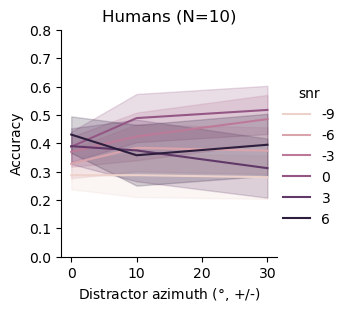

In [9]:
to_plot = results_df[(results_df.n_distractors == 2)
                     & (results_df.participant != 'participant_001' ) 
                               ]

N = to_plot.participant.nunique()
print(N)
g = sns.relplot(data=to_plot,
                x='distractor_azim', y='correct', hue="snr",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                # col='target_elev', 
                # palette=palette, 
                errorbar=('se', 2),
                height=3, aspect=1)

g.set_axis_labels("SNR (dB)", "Accuracy")
g.set_titles("{col_name}")


plt.title(f'Humans (N={N})')
g.set( xticks=np.arange(0, 31, 10))
plt.ylim(0,0.8)
g.set_axis_labels("Distractor azimuth ($\degree$, +/-)", "Accuracy")
# set titles 
# g.set_titles("Target elevation: {row_name}\n{col_name}")

In [10]:
grouped_part_results.columns

Index(['participant', 'target_azim', 'target_elev', 'distractor_azim',
       'distractor_elev', 'snr', 'n_distractors', 'correct_mean',
       'correct_sem', 'confusions_mean', 'confusions_sem', 'confusions_count'],
      dtype='object')

/tmp/ipykernel_163568/3130735891.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['elev_delta'] = (to_plot['target_elev'] - to_plot['distractor_elev']).abs()


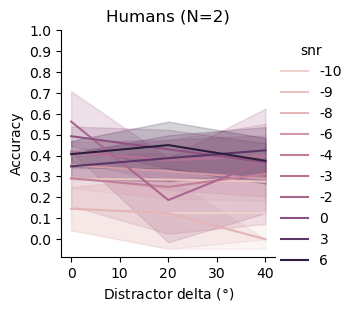

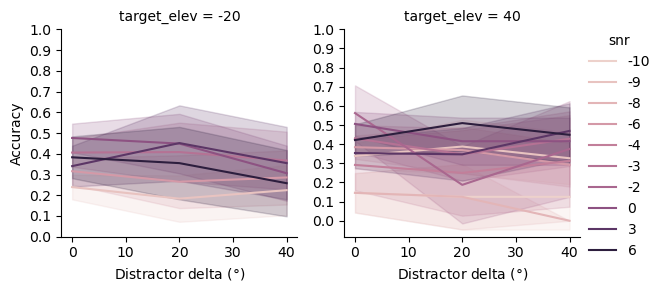

In [11]:
to_plot = results_df[results_df.n_distractors == 2]
# to_plot = results_df[#(results_df.n_distractors == 1)
#                      (results_df.participant != 'participant_001' ) 
                            #    ]
to_plot['elev_delta'] = (to_plot['target_elev'] - to_plot['distractor_elev']).abs()

g = sns.relplot(data=to_plot,
                x='elev_delta', y='correct', hue="snr",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                # col='target_elev', 
                # palette=palette, 
                errorbar=('se', 2),
                height=3, aspect=1)
plt.title('Humans (N=2)')
g.set(yticks=np.arange(0, 1.1, .1), xticks=np.arange(0, 41, 10))
# plt.ylim(0,0.8)
g.set_axis_labels("Distractor delta ($\degree$)", "Accuracy")
# set titles 
# g.set_titles("Target elevation: {row_name}\n{col_name}")
g = sns.relplot(data=to_plot,
                x='elev_delta', y='correct', hue="snr",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                col='target_elev', 
                # palette=palette, 
                errorbar=('se', 2),
                height=3, aspect=1)
# plt.title('Humans (N=2)')
g.set(yticks=np.arange(0, 1.1, .1), xticks=np.arange(0, 41, 10))
# plt.ylim(0,0.8)
g.set_axis_labels("Distractor delta ($\degree$)", "Accuracy")
# set titles 


### Threshold estimate proceedure

Will be plotting grand average thresholds:
1) average participant data per condition
2) fit thresholds to averaged data
3) bootstrap over participants for error bars 

Actual implementation will use pandas and seaborn to plot average, just need to save individual bootstraps



In [12]:
# avg_df

In [14]:
### Make threshold dataframe 

## First, get grand average. Then bootstrap for error 

# avg threshold estimates 
grouped_part_results['distractor_elev_delta'] = (grouped_part_results['target_elev'] - grouped_part_results['distractor_elev']).abs()

# avg_thresholds = []
# avg_df = grouped_part_results.groupby(['distractor_azim', 'distractor_elev_delta', 'snr']).agg({'correct_mean':'mean'}).reset_index()
# for (dist_azim, dist_elev), group in avg_df.groupby(['distractor_azim', 'distractor_elev_delta', ]):
#     thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean.values)
#     avg_thresholds.append({'dist_azim':dist_azim, 'dist_elev_delta':dist_elev,  'threshold':thresh})
# avg_thresh_df = pd.DataFrame(avg_thresholds)
# avg_thresh_df

thresholds = []
for (participant, target_azim, target_elev, dist_azim, dist_elev, n_dist), group in grouped_part_results.groupby(['participant', 'target_azim', 'target_elev', 'distractor_azim', 'distractor_elev', 'n_distractors']): #, 'gender_cond']):
	thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean.values, bounds_from_data=True)
	if np.isnan(thresh):
		print(f"Threshold is nan for {participant}, {target_azim}, {target_elev}, {dist_azim}, {dist_elev}, {n_dist}")
	thresholds.append({'participant':participant, 'target_azim':target_azim, 'target_elev':target_elev, 
					   'dist_azim':dist_azim, 'dist_elev':dist_elev, 'n_distractors':n_dist,'threshold':thresh}) #  'gender_cond':gend_cond,
    
human_thresh_df = pd.DataFrame(thresholds)


/net/vast-storage/scratch/vast/mcdermott/imgriff/projects/torch_2_aud_attn/src/util_analysis.py:21: RuntimeWarning: invalid value encountered in divide
  p0 = (1, x[np.argmin(np.abs(np.cumsum(y) / np.sum(y) - 0.5))], 1)


ValueError: array must not contain infs or NaNs

In [ ]:
human_thresh_df

,participant,target_azim,target_elev,dist_azim,dist_elev,n_distractors,threshold
0,participant_001,0,40,0,0,2,NaN
1,participant_001,0,40,0,20,2,NaN
2,participant_001,0,40,0,40,2,-3.952574
3,participant_001,0,40,10,40,2,110.139685
4,participant_001,0,40,30,40,2,59.200423
5,participant_002,0,-20,0,-20,2,4.803398
6,participant_002,0,-20,0,0,2,-5.225886
7,participant_002,0,-20,0,20,2,-8.385762
8,participant_002,0,-20,10,-20,2,61.624053
9,participant_002,0,-20,30,-20,2,-5.711723


In [15]:
to_plot = human_thresh_df[human_thresh_df.n_distractors==2]

## Clip for plotting 
human_thresh_df.loc[human_thresh_df['threshold'] < -10, 'threshold'] = -10
human_thresh_df.loc[human_thresh_df['threshold'] > 0, 'threshold'] = 0
to_plot['distractor_azim'] = to_plot.dist_azim.abs()

g = sns.relplot(data=to_plot, x='distractor_azim', y='threshold', kind='line',
                # hue='gender_cond',
                # style='room_ix',
                # error_ba
                height=3.5, aspect=1)
# update legend 

g.set_axis_labels("Distractor azimuth ($\degree$, +/-)", "Threshold TMR (dB)")
g.set(yticks=np.arange(-12,1,3) , xticks=np.arange(0, 31, 10))
ratio = 1 
for ax in g.axes.flat:
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1.5)
        

g = sns.relplot(data=to_plot, x='distractor_azim', y='threshold', kind='line',
                # hue='gender_cond',
                col='target_elev',
                # style='room_ix',
                height=3.5, aspect=1)
# update legend 

g.set_axis_labels("Distractor azimuth ($\degree$, +/-)", "Threshold TMR (dB)")
g.set(yticks=np.arange(-12,1,3) , xticks=np.arange(0, 31, 10))
ratio = 1 
for ax in g.axes.flat:
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1.5)

NameError: name 'human_thresh_df' is not defined

In [16]:
to_plot = human_thresh_df[human_thresh_df.n_distractors==2]
to_plot['elev_delta'] = (to_plot['target_elev'] - to_plot['dist_elev']).abs()

g = sns.relplot(data=to_plot, x='elev_delta', y='threshold', kind='line',
                # hue='gender_cond',
                # style='room_ix',
                height=3.5, aspect=1)
# update legend 

g.set_axis_labels("Elevation delta ($\degree$)", "Threshold TMR (dB)")
# g.set(yticks=np.arange(-12,1,3) , xticks=np.arange(0, 31, 10))
ratio = 1 
for ax in g.axes.flat:
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1.5)

NameError: name 'human_thresh_df' is not defined

In [17]:
to_plot

,trial_num,response,correct_response,correct,target_loc,distractor_loc,azim_delta,elev_delta,snr,target_word,distractor_word,target_azim,target_elev,distractor_azim,distractor_elev,n_distractors,participant,confusions
0,0,final,child,0.0,"(0, -20)","[(-30, -20), (30, -20)]",30,0,-9,child,"[period, carried]",0,-20,30,-20,2,pilot_participant_002,0
1,1,meaning,seven,0.0,"(0, -20)","[(0, -20), (0, -20)]",0,0,-6,seven,"[science, after]",0,-20,0,-20,2,pilot_participant_002,0
2,2,central,central,1.0,"(0, -20)","[(-30, -20), (30, -20)]",30,0,0,central,"[between, through]",0,-20,30,-20,2,pilot_participant_002,0
3,3,brother,brother,1.0,"(0, -20)","[(0, -20), (0, -20)]",0,0,0,brother,"[against, eight]",0,-20,0,-20,2,pilot_participant_002,0
4,4,decided,talking,0.0,"(0, -20)","[(-10, -20), (10, -20)]",10,0,-9,talking,"[system, today]",0,-20,10,-20,2,pilot_participant_002,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5155,475,centre,center,0.0,"(0, 40)","[(0, 0), (0, 0)]",0,40,0,least,"[health, seemed]",0,40,0,0,2,participant_008,0
5156,476,similar,similar,1.0,"(0, 40)","[(0, 20), (0, 20)]",0,20,-9,regular,"[instead, leave]",0,40,0,20,2,participant_008,0
5157,477,night,night,1.0,"(0, 40)","[(0, 0), (0, 0)]",0,40,-3,across,"[however, through]",0,40,0,0,2,participant_008,0
5158,478,instead,instead,1.0,"(0, 40)","[(0, 0), (0, 0)]",0,40,3,related,"[front, again]",0,40,0,0,2,participant_008,0


In [18]:
to_plot = human_thresh_df[human_thresh_df.n_distractors==1]
to_plot['elev_delta'] = (to_plot['target_elev'] - to_plot['dist_elev']).abs()

g = sns.relplot(data=to_plot, x='elev_delta', y='threshold', kind='line',
                # hue='gender_cond',
                col='target_elev',
                # style='room_ix',
                height=3.5, aspect=1)
# update legend 

g.set_axis_labels("Elevation delta ($\degree$)", "Threshold TMR (dB)")
# g.set(yticks=np.arange(-12,1,3) , xticks=np.arange(0, 31, 10))
ratio = 1 
for ax in g.axes.flat:
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1.5)

NameError: name 'human_thresh_df' is not defined

## Load model data and meta files

In [2]:
room_manifest = pd.read_pickle('/om2/user/msaddler/spatial_audio_pipeline/assets/brir/eval/manifest_room.pdpkl')
# for tuple_ in room_manifest.itertuples():
#     print(tuple_)
#     break
room_material_map = {}
for row in room_manifest.itertuples():
    wall1 = row.material_x0[0].split(',')[0]
    wall2 = row.material_y1[0].split(',')[0]
    if wall1 == wall2:
        wall_str = f"{wall1} walls"
    else:
        wall_str = f"{wall1} and {wall2} walls"

    floor = row.material_z0[0].split(',')[0]
    ceiling = row.material_z1[0].split(',')[0]
    name_str = f"{wall_str} \n {floor} floor \n {ceiling} ceiling"

    if row.index_room in [5, 6]:
        name_str = 'Alternate speaker room'
    if row.index_room in [6, 8]:
        name_str += ' \n head rotated'
    else:
        head_rotated = ''
    if 'Anechoic' in name_str:
        name_str = "Anechoic"
    room_material_map[row.index_room] = name_str
# room_material_map = {row.index_room: f"{row.material_x0[0].split(',')[0]} and \n {row.material_y1[0].split(',')[0]} walls \n {row.material_z0[0].split(',')[0]} floor \n {row.material_z1[0].split(',')[0]} ceiling" for row in room_manifest.itertuples()}
# room_material_map[5] = 'standard speaker room'
room_material_map

{0: 'Anechoic',
 1: 'Wood panelling on glass fiber blanket walls \n Carpet on foam rubber padding floor \n Highly absorptive panels ceiling',
 2: 'Brick walls \n Wood parquet on concrete floor \n Plaster ceiling',
 3: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling',
 4: 'Concrete walls \n Linoleum floor \n Acoustic tiles ceiling',
 5: 'Alternate speaker room',
 6: 'Alternate speaker room \n head rotated',
 7: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling',
 8: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling \n head rotated'}

In [3]:
import pickle 

# manifest_path = "binaural_test_manifests/sim_2024_human_experiment.pkl"
manifest_path = "binaural_test_manifests/symmetric_distractor_conditions_w_front_back_neg_21_to_6_dBSNR_min_reverb_mit_room.pkl"
with open(manifest_path, "rb") as f: 
    manifest = pickle.load(f)
    

In [4]:
manifest_df  = pd.DataFrame(manifest.values())
manifest_df

,target_loc,distract_loc,snr,symmetric_distractor,test_room_meta
0,"(0, -20)","[0, -20]",6.0,True,{'room_manifest': '/om2/user/imgriff/spatial_a...
1,"(0, -20)","[0, -20]",3.0,True,{'room_manifest': '/om2/user/imgriff/spatial_a...
2,"(0, -20)","[0, -20]",0.0,True,{'room_manifest': '/om2/user/imgriff/spatial_a...
3,"(0, -20)","[0, -20]",-3.0,True,{'room_manifest': '/om2/user/imgriff/spatial_a...
4,"(0, -20)","[0, -20]",-6.0,True,{'room_manifest': '/om2/user/imgriff/spatial_a...
...,...,...,...,...,...
415,"(0, 40)","[0, 0]",-9.0,False,{'room_manifest': '/om2/user/imgriff/spatial_a...
416,"(0, 40)","[0, 0]",-12.0,False,{'room_manifest': '/om2/user/imgriff/spatial_a...
417,"(0, 40)","[0, 0]",-15.0,False,{'room_manifest': '/om2/user/imgriff/spatial_a...
418,"(0, 40)","[0, 0]",-18.0,False,{'room_manifest': '/om2/user/imgriff/spatial_a...


In [5]:
# spkr_room_manifest = pd.read_pickle('/om2/user/msaddler/spatial_audio_pipeline/assets/brir/mit_bldg46room1004/manifest_room.pdpkl')
spkr_room_manifest = pd.read_pickle('/om2/user/imgriff/spatial_audio_pipeline/assets/brir/mit_bldg46room1004_min_reverb/manifest_room.pdpkl')

In [6]:

spkr_room_manifest

,head_azim,head_pos_xyz,index_room,is_outdoor,material_x0,material_x1,material_y0,material_y1,material_z0,material_z1,room_dim_xyz,room_materials
0,0,"[2.3, 3.6, 0.9]",0,False,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,carpet on foam rubber padding,"highly absorptive panels, 1in, 16in below ceiling","[4.66, 5.9, 2.48]","[11, 11, 11, 11, 15, 20]"
1,0,"[3.6, 2.36, 0.9]",1,False,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,carpet on foam rubber padding,"highly absorptive panels, 1in, 16in below ceiling","[5.9, 4.66, 2.48]","[11, 11, 11, 11, 15, 20]"
2,0,"[2.36, 2.3, 0.9]",2,False,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,carpet on foam rubber padding,"highly absorptive panels, 1in, 16in below ceiling","[4.66, 5.9, 2.48]","[11, 11, 11, 11, 15, 20]"
3,0,"[2.3, 2.3, 0.9]",3,False,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,carpet on foam rubber padding,"highly absorptive panels, 1in, 16in below ceiling","[5.9, 4.66, 2.48]","[11, 11, 11, 11, 15, 20]"


In [8]:
# Path to results 
# output_paths = list(Path("binaural_eval/word_task_voice_loc_cue_only_v04").glob("*.pkl")) old path for more locations

# match human pilot conditions
# model_name = 'word_task_half_co_loc_v06'
# output_paths = list(Path(f"binaural_eval/simulate_2024_human_array_experiment/").glob("*/*room*.pkl"))

output_paths = list(Path(f"binaural_eval/simulate_2024_human_array_experiment_sanity_check/").glob("*/*.pkl"))
stim_manifest_df = pd.read_pickle('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta.pdpkl')

## Get anechoic room for comparison 
# output_paths += list(Path(f"binaural_eval/symmetric_distractor_test/").glob("*/*eval*room0000.pkl"))
# anech_stim_manifest_df = pd.read_pickle('/om2/user/rphess/Auditory-Attention/final_binaural_manifest.pkl')
 
word_class_map = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
ix_to_word = {v:k for k,v in word_class_map.items()}

remap_azim = lambda azim: 360 - azim if azim > 180 else 0 - azim 

results_dfs = []

gend_map = {True:'same', False:'different'}

for path in output_paths:
    if not any(name in str(path) for name in ['word_task_half_co_loc_v08_gender_bal_4M_sanity']):# 'word_task_half_co_loc_v08']):
        continue
    if 'modulated' in path.stem:
        continue 
    res_dict = pickle.load(open(path, 'rb'))
    df = pd.DataFrame.from_dict(res_dict)
    # break
    df.rename(columns={"results": "accuracy"}, inplace=True)
    df['model'] = path.parent.stem

    # if not 'min' in path.stem: 
    #     df = df.join(anech_stim_manifest_df[['word', 'bg_word','gender', 'bg_gender']], how='outer')
    #     df.rename(columns={'bg_word':"distractor_word"}, inplace=True)  
    #     df['sex_cond'] = df["gender"].values == df['bg_gender'].values
    #     df['sex_cond'] =  df['sex_cond'].map(gend_map)
    # else:
    # # # merge with stim manifest
    df.loc[df.index.values, ['word', 'distractor_word','sex_cond']] = stim_manifest_df.loc[df.stim_ix_list.values, ['word', 'distractor_word','sex_cond']].values
    df['target_word'] = df['true_word_int'].map(ix_to_word)
    df['pred_word'] = df['preds'].map(ix_to_word)
    df['correct'] = (df['true_word_int'] == df['preds']).astype('int')
    df['str_confusions'] = df[['pred_word', 'distractor_word']].apply(lambda x: 1 if x.pred_word in x.distractor_word else 0, axis=1)
    if 'clean' in path.stem:
        snr = 'clean'
    else:
        snr = int(re.search('(-?\d+)_SNR', path.stem).group(0).strip('_SNR'))
        
    df['snr'] = snr 
    df["target_azim"], df["target_elev"] = path.stem.split('target_loc_')[1].split('_distract_loc_')[0].split('_')
    df["distractor_azim"], df["distractor_elev"] = path.stem.split('_distract_loc_')[1].split('_')[:2]
    # # map azim to 0-180
    df['target_azim'] = df['target_azim'].astype(int).apply(remap_azim)
    df['distractor_azim'] = df['distractor_azim'].astype(int).apply(remap_azim)
    df['target_elev'] = df['target_elev'].astype(int)
    df['distractor_elev'] = df['distractor_elev'].astype(int)
    df['room_ix'] = int(re.search('room(-?\d+)', path.stem).group(0).strip('room'))
    df['room_type'] = re.search('SNR_(.*?)_room', path.stem).group(0).split('SNR_')[-1].split("_room")[0]
    df['n_distractors'] = 1 if '1_distractor' in path.stem else 2
    df['test_set'] = 'all_stim' if 'all_stim' in path.stem else 'subset'
    df['distractor_type'] = 'speech'
    results_dfs.append(df)

results = pd.concat(results_dfs)

In [9]:
### Get noise test results
# Path to results 
# output_paths = list(Path("binaural_eval/word_task_voice_loc_cue_only_v04").glob("*.pkl")) old path for more locations

# match human pilot conditions
# model_name = 'word_task_half_co_loc_v06'
# output_paths = list(Path(f"binaural_eval/simulate_2024_human_array_experiment/").glob("*/*room*.pkl"))

output_paths = list(Path(f"binaural_eval/simulate_2024_human_array_experiment_white_noise_dist/").glob("*/*.pkl"))
stim_manifest_df = pd.read_pickle('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta.pdpkl')

## Get anechoic room for comparison 
# output_paths += list(Path(f"binaural_eval/symmetric_distractor_test/").glob("*/*eval*room0000.pkl"))
# anech_stim_manifest_df = pd.read_pickle('/om2/user/rphess/Auditory-Attention/final_binaural_manifest.pkl')
 
word_class_map = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
ix_to_word = {v:k for k,v in word_class_map.items()}

remap_azim = lambda azim: 360 - azim if azim > 180 else 0 - azim 

results_dfs = []

gend_map = {True:'same', False:'different'}

for path in output_paths:
    if not any(name in str(path) for name in ['word_task_half_co_loc_v08_gender_bal_4M_sanity']):# 'word_task_half_co_loc_v08']):
        continue
    if 'modulated' in path.stem:
        continue 
    res_dict = pickle.load(open(path, 'rb'))
    df = pd.DataFrame.from_dict(res_dict)
    # break
    df.rename(columns={"results": "accuracy"}, inplace=True)
    df['model'] = path.parent.stem

    # if not 'min' in path.stem: 
    #     df = df.join(anech_stim_manifest_df[['word', 'bg_word','gender', 'bg_gender']], how='outer')
    #     df.rename(columns={'bg_word':"distractor_word"}, inplace=True)  
    #     df['sex_cond'] = df["gender"].values == df['bg_gender'].values
    #     df['sex_cond'] =  df['sex_cond'].map(gend_map)
    # else:
    # # # merge with stim manifest
    df.loc[df.index.values, ['word', 'distractor_word','sex_cond']] = stim_manifest_df.loc[df.stim_ix_list.values, ['word', 'distractor_word','sex_cond']].values
    df['target_word'] = df['true_word_int'].map(ix_to_word)
    df['pred_word'] = df['preds'].map(ix_to_word)
    df['correct'] = (df['true_word_int'] == df['preds']).astype('int')
    df['str_confusions'] = df[['pred_word', 'distractor_word']].apply(lambda x: 1 if x.pred_word in x.distractor_word else 0, axis=1)
    if 'clean' in path.stem:
        snr = 'clean'
    else:
        snr = int(re.search('(-?\d+)_SNR', path.stem).group(0).strip('_SNR'))
        
    df['snr'] = snr 
    df["target_azim"], df["target_elev"] = path.stem.split('target_loc_')[1].split('_distract_loc_')[0].split('_')
    df["distractor_azim"], df["distractor_elev"] = path.stem.split('_distract_loc_')[1].split('_')[:2]
    # # map azim to 0-180
    df['target_azim'] = df['target_azim'].astype(int).apply(remap_azim)
    df['distractor_azim'] = df['distractor_azim'].astype(int).apply(remap_azim)
    df['target_elev'] = df['target_elev'].astype(int)
    df['distractor_elev'] = df['distractor_elev'].astype(int)
    df['room_ix'] = int(re.search('room(-?\d+)', path.stem).group(0).strip('room'))
    df['room_type'] = re.search('SNR_(.*?)_room', path.stem).group(0).split('SNR_')[-1].split("_room")[0]
    df['n_distractors'] = 1 if '1_distractor' in path.stem else 2
    df['test_set'] = 'all_stim' if 'all_stim' in path.stem else 'subset'
    df['distractor_type'] = 'white_noise'
    results_dfs.append(df)

noise_results = pd.concat(results_dfs)

In [10]:
re.search('SNR_(.*?)_room', path.stem).group(0)

'SNR_mitb46_room'

In [11]:
results = pd.concat([results, noise_results], ignore_index=True)

In [12]:
results.room_type.unique()

array(['eval', 'min_reverb', 'mitb46'], dtype=object)

In [13]:
results.loc[results.room_type == 'eval', 'room_str'] = results.loc[results.room_type == 'eval', 'room_ix'].map(room_material_map)

results.loc[results.room_type == 'mitb46', 'room_str'] = 'Normal speaker array'
results.loc[results.room_type == 'mitb46', 'room_ix'] = 9 # use n from diff room notebook

results.loc[results.room_type.str.contains('reverb'), 'room_str'] = 'Min. reverb speaker array'
results.loc[results.room_type.str.contains('reverb'), 'room_ix'] = 10 # use n from diff room notebook

In [14]:
# results[(results.target_azim == results.distractor_azim) & (results.target_elev != results.distractor_elev)]

In [15]:
grouped_model_results = results.groupby(['model', 'target_azim', 'target_elev', 'distractor_azim', 'test_set', 'distractor_type',
                                   'distractor_elev', 'sex_cond', 'snr', 'n_distractors', 'room_str']).agg({'accuracy':['mean', 'sem'],
                                                                                                                     'confusions':['mean', 'sem']}).reset_index()
# flatten multiindex
grouped_model_results.columns = ['_'.join(col).strip() for col in grouped_model_results.columns.values]
# remove trailing underscore
grouped_model_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_model_results.columns.values]



In [16]:
grouped_model_results

,model,target_azim,target_elev,distractor_azim,test_set,distractor_type,distractor_elev,sex_cond,snr,n_distractors,room_str,accuracy_mean,accuracy_sem,confusions_mean,confusions_sem
0,word_task_half_co_loc_v08_gender_bal_4M_sanity,0,-20,-180,all_stim,speech,-20,different,-21,2,Anechoic,0.027664,0.005252,0.310451,0.014818
1,word_task_half_co_loc_v08_gender_bal_4M_sanity,0,-20,-180,all_stim,speech,-20,different,-21,2,Min. reverb speaker array,0.014344,0.003808,0.298156,0.014650
2,word_task_half_co_loc_v08_gender_bal_4M_sanity,0,-20,-180,all_stim,speech,-20,different,-21,2,Normal speaker array,0.011270,0.003381,0.283811,0.014439
3,word_task_half_co_loc_v08_gender_bal_4M_sanity,0,-20,-180,all_stim,speech,-20,different,-18,2,Anechoic,0.050205,0.006993,0.265369,0.014140
4,word_task_half_co_loc_v08_gender_bal_4M_sanity,0,-20,-180,all_stim,speech,-20,different,-18,2,Min. reverb speaker array,0.033811,0.005788,0.262295,0.014088
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4715,word_task_half_co_loc_v08_gender_bal_4M_sanity,0,40,0,all_stim,white_noise,40,same,6,1,Min. reverb speaker array,0.743852,0.013979,0.001025,0.001025
4716,word_task_half_co_loc_v08_gender_bal_4M_sanity,0,40,0,all_stim,white_noise,40,same,6,1,Normal speaker array,0.643443,0.015340,0.000000,0.000000
4717,word_task_half_co_loc_v08_gender_bal_4M_sanity,0,40,0,all_stim,white_noise,40,same,6,2,Anechoic,0.752049,0.013829,0.003074,0.001773
4718,word_task_half_co_loc_v08_gender_bal_4M_sanity,0,40,0,all_stim,white_noise,40,same,6,2,Min. reverb speaker array,0.738730,0.014070,0.002049,0.001448


/tmp/ipykernel_310489/897559462.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot.distractor_azim = to_plot.distractor_azim.abs()


<Figure size 640x480 with 0 Axes>

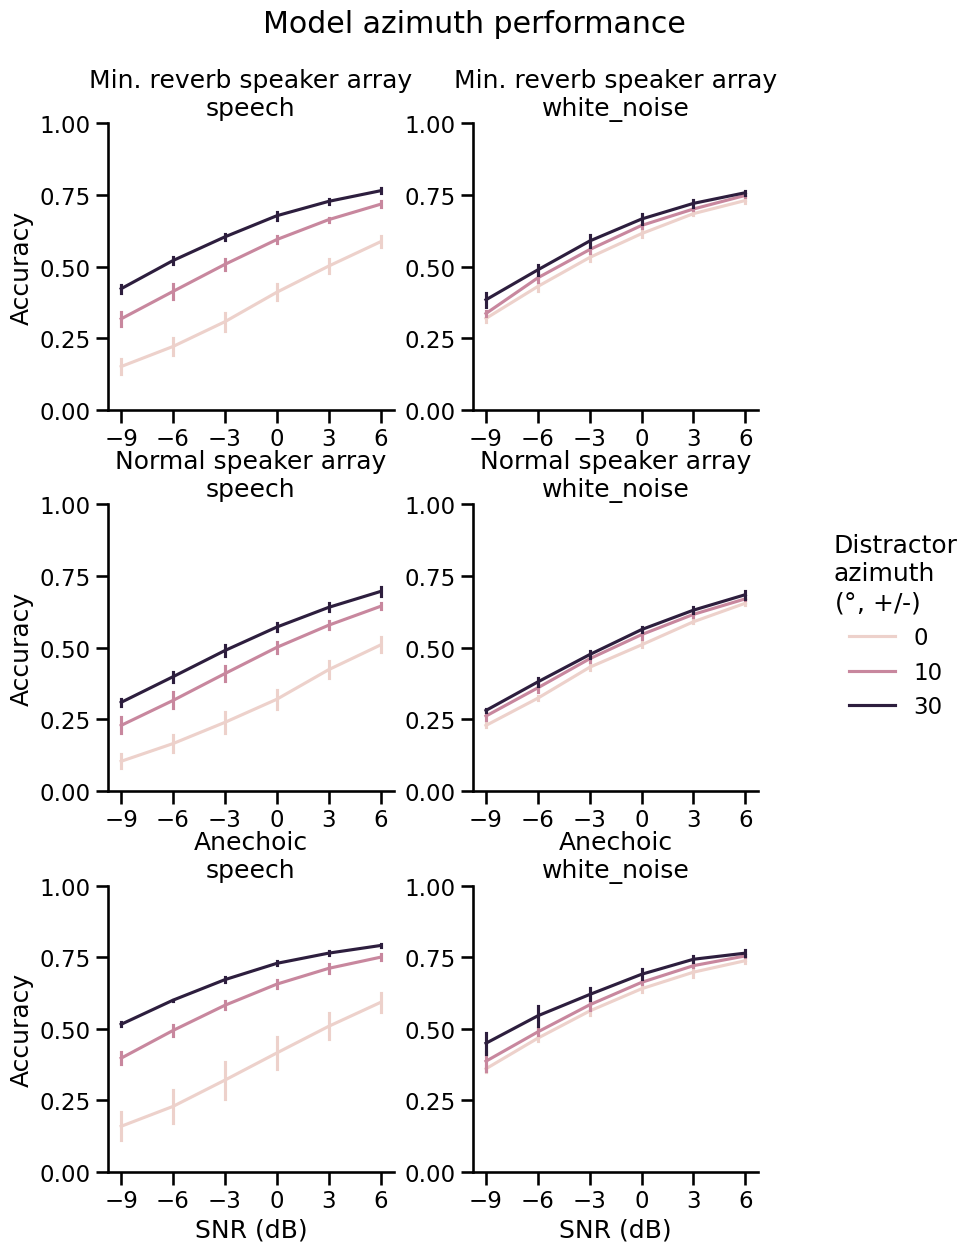

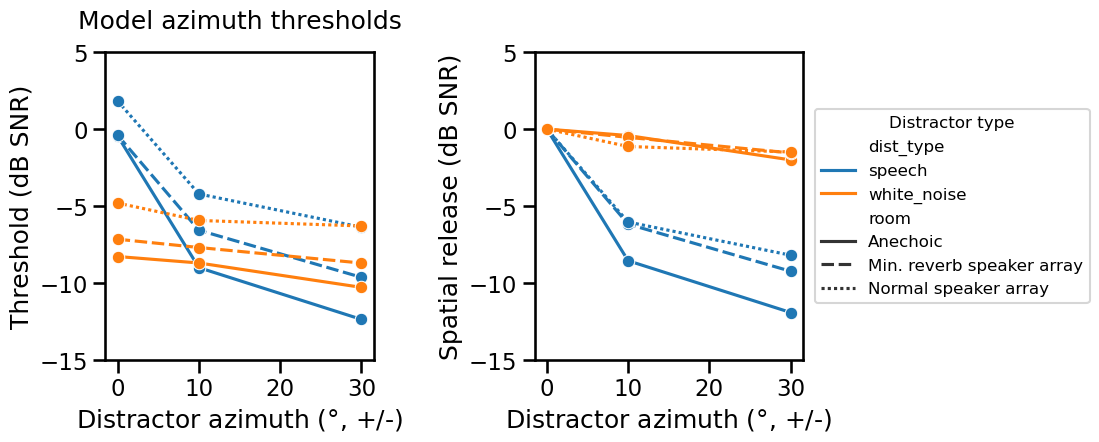

In [26]:


## First, get grand average. Then bootstrap for error 
sns.set_context('talk')

# avg threshold estimates for 0 and 10 azimuth separation 
to_plot = grouped_model_results[
                    (grouped_model_results.n_distractors == 2)
                        #   & (grouped_model_results.room_str == 'Min. reverb speaker array')
                          & (grouped_model_results.model == 'word_task_half_co_loc_v08_gender_bal_4M_sanity')
                         & (grouped_model_results.distractor_azim.isin([0, -10, -30])) 
                        #   & (grouped_model_results.snr.isin([6,3, 0, -3, -6, -9,]))
                          ]

to_plot.distractor_azim = to_plot.distractor_azim.abs()                    
azim_results_for_thresh = to_plot.groupby(['model','room_str', 'distractor_azim', 'distractor_type', 'snr']).agg({'accuracy_mean':'mean'}).reset_index()



azim_thresholds = []
# p0 = [0.0, -4, 4]
for (model, room, dist_type, azim), group in azim_results_for_thresh.groupby(['model', 'room_str', 'distractor_type', 'distractor_azim']): #, 'gender_cond']):
    thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.accuracy_mean.values, bounds_from_data=True)#, p0=p0)
    if np.isnan(thresh):
        print(f"Threshold is nan for azim {azim}")
    azim_thresholds.append({'model': model, "room":room, "dist_type":dist_type, 'azim': azim, 'threshold':thresh}) #  'gender_cond':gend_cond,
    
azim_thresh_df = pd.DataFrame(azim_thresholds)


plt.figure()
g = sns.relplot(data=to_plot[to_plot.snr.isin([6,3, 0, -3, -6, -9,])],
                x='snr', y='accuracy_mean', hue="distractor_azim",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                col='distractor_type', 
                row='room_str',
                # palette=palette, 
                errorbar=('se', 2),
                err_style='bars',
                height=4, aspect=1)
g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
new_title = 'Distractor\nazimuth\n($\degree$, +/-)'
g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
# column titles 
g.set_titles("{row_name}\n{col_name}")
plt.suptitle(f'Model azimuth performance', y=1.05)

# plot azim thresholds
# sns.set_style('white')
fig, axs = plt.subplots(1,2, figsize=(9, 4))
g = sns.lineplot(data=azim_thresh_df, x='azim', y='threshold', hue='dist_type', style='room', marker='o', ax=axs[0],  legend=False)
# axs[0].set_title(f'Model azimuth thresholds', y=1.05)
axs[0].set_title(f'Model azimuth thresholds', y=1.05)

axs[0].set_xlabel('Distractor azimuth ($\degree$, +/-)')
axs[0].set_ylabel("Threshold (dB SNR)")
axs[0].set_ylim(-15,5)
axs[0].set_xticks(np.arange(0, 31, 10))

# get srm per model
for model in azim_thresh_df.model.unique():
    for dist_type in azim_thresh_df.dist_type.unique():
        for room_type in azim_thresh_df.room.unique():
            ixs = (azim_thresh_df.model == model) & (azim_thresh_df.dist_type == dist_type) & (azim_thresh_df.room == room_type)
            model_data = azim_thresh_df[ixs]
            azim_thresh_df.loc[ixs, 'srm'] = model_data.threshold - model_data.threshold.max()
# sns.set_style('white')
g = sns.lineplot(data=azim_thresh_df, x='azim', y='srm', hue='dist_type', style='room', marker='o', ax=axs[1], legend=True)
# axs[1].set_title(f'Model azimuth spatial release', y=1.05)
axs[1].set_xlabel('Distractor azimuth ($\degree$, +/-)')
axs[1].set_ylabel("Spatial release (dB SNR)")
axs[1].set_ylim(-15,5)
axs[1].set_xticks(np.arange(0, 31, 10))

# adjust w space 
plt.subplots_adjust(wspace=0.6)
# adjust legend 
handles, labels = axs[1].get_legend_handles_labels()
axs[1].legend(handles=handles, labels=labels, title='Distractor type', loc='center right', fontsize=12, title_fontsize=12, bbox_to_anchor=(2.1, 0.5))



/tmp/ipykernel_310489/1763542793.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['elev_delta'] = (to_plot['target_elev'] - to_plot['distractor_elev']).abs()


<Figure size 640x480 with 0 Axes>

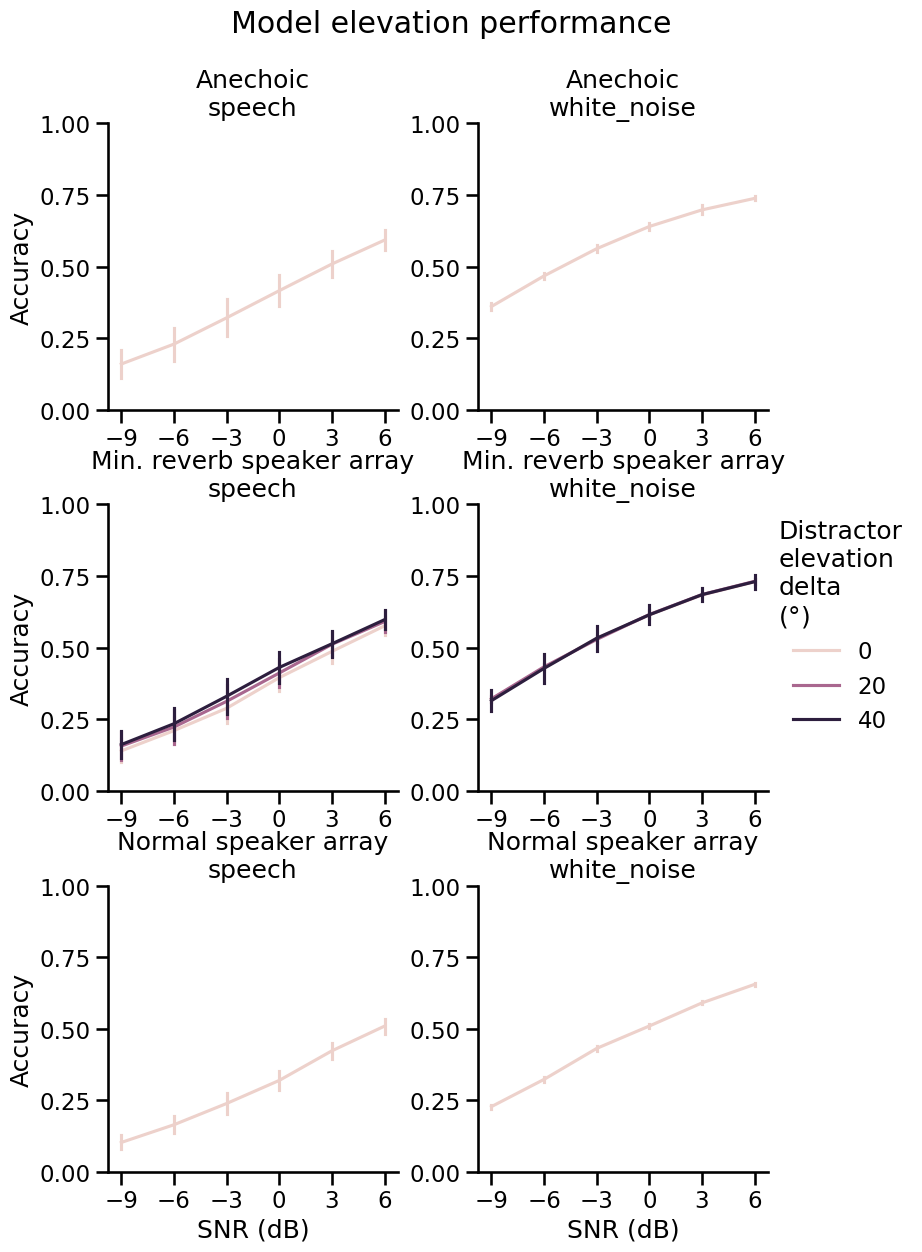

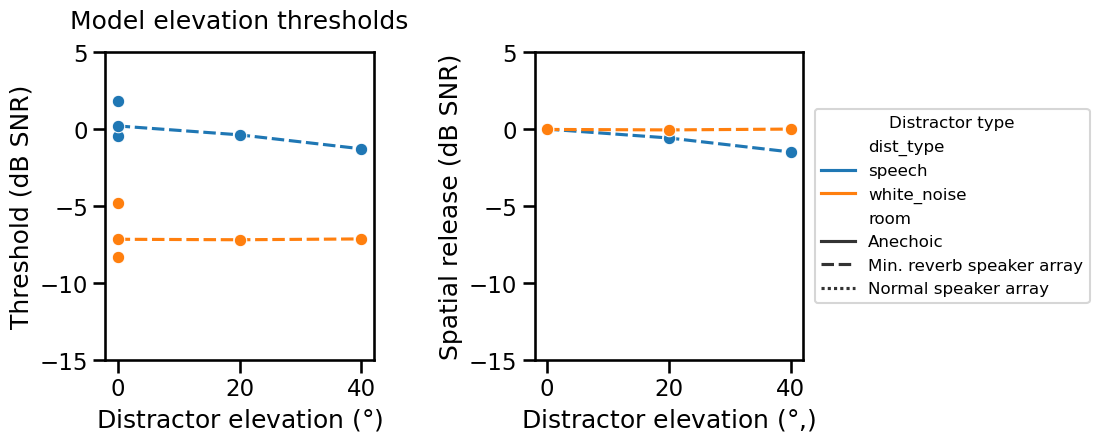

In [31]:


## First, get grand average. Then bootstrap for error 
sns.set_context('talk')

# avg threshold estimates for 0 and 10 elevation separation 
to_plot = grouped_model_results[
                    (grouped_model_results.n_distractors == 2)
                        #   & (grouped_model_results.room_str == 'Min. reverb speaker array')
                          & (grouped_model_results.model == 'word_task_half_co_loc_v08_gender_bal_4M_sanity')
                        &	(grouped_model_results.distractor_azim == 0) 
                        #   & (grouped_model_results.snr.isin([6,3, 0, -3, -6, -9]))
                          ]

to_plot['elev_delta'] = (to_plot['target_elev'] - to_plot['distractor_elev']).abs()

elev_results_for_thresh = to_plot.groupby(['model', 'room_str', 'elev_delta', 'distractor_type', 'snr']).agg({'accuracy_mean':'mean'}).reset_index()



azim_thresholds = []
# p0 = [0.0, -4, 4]
for (model, room, dist_type, elev_delta), group in elev_results_for_thresh.groupby(['model', 'room_str', 'distractor_type', 'elev_delta']): #, 'gender_cond']):
    thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.accuracy_mean.values, bounds_from_data=True)#, p0=p0)
    if np.isnan(thresh):
        print(f"Threshold is nan for elev {elev_delta}")
    azim_thresholds.append({'model':model, "room":room, "dist_type":dist_type, 'elev_delta': elev_delta, 'threshold':thresh}) #  'gender_cond':gend_cond,
    
elev_thresh_df = pd.DataFrame(azim_thresholds)


plt.figure()
g = sns.relplot(data=to_plot[(to_plot.snr.isin([6,3, 0, -3, -6, -9]))],
                x='snr', y='accuracy_mean', hue="elev_delta",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                col='distractor_type', 
                row='room_str',
                # palette=palette, 
                errorbar=('se', 2),
                err_style='bars',
                height=4, aspect=1)
g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
new_title = 'Distractor\nelevation\ndelta\n($\degree$)'
g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
# plt.title(f'Model elevation performance', y=1.05)
g.set_titles("{row_name}\n{col_name}")
plt.suptitle(f'Model elevation performance', y=1.05)

# plot azim thresholds
# sns.set_style('white')
fig, axs = plt.subplots(1,2, figsize=(9, 4))
g = sns.lineplot(data=elev_thresh_df, x='elev_delta', y='threshold',  hue='dist_type', style='room', marker='o', ax=axs[0], legend=False)
axs[0].set_title(f'Model elevation thresholds', y=1.05)
axs[0].set_xlabel('Distractor elevation ($\degree$)')
axs[0].set_ylabel("Threshold (dB SNR)")
axs[0].set_ylim(-15,5)

for model in elev_thresh_df.model.unique():
    for dist_type in elev_thresh_df.dist_type.unique():
        for room_type in elev_thresh_df.room.unique():
            ixs = (elev_thresh_df.model == model) & (elev_thresh_df.dist_type == dist_type) & (elev_thresh_df.room == room_type)
            model_data = elev_thresh_df[ixs]
            elev_thresh_df.loc[ixs, 'srm'] = model_data.threshold - model_data.threshold.max()

# sns.set_style('white')
# plt.figure(figsize=(4, 4))
g = sns.lineplot(data=elev_thresh_df, x='elev_delta', y='srm',  hue='dist_type', style='room', marker='o', ax=axs[1], legend=True)
# plt.title(f'Model elevation spatial release', y=1.05)
axs[1].set_xlabel('Distractor elevation ($\degree$,)')
axs[1].set_ylabel("Spatial release (dB SNR)")
axs[1].set_ylim(-15,5)

# adjust w space 
plt.subplots_adjust(wspace=0.6)
# adjust w space 
plt.subplots_adjust(wspace=0.6)
# adjust legend 
handles, labels = axs[1].get_legend_handles_labels()
axs[1].legend(handles=handles, labels=labels, title='Distractor type', loc='center right', fontsize=12, title_fontsize=12, bbox_to_anchor=(2.1, 0.5))


/tmp/ipykernel_586471/55910426.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot.distractor_azim = to_plot.distractor_azim.abs()


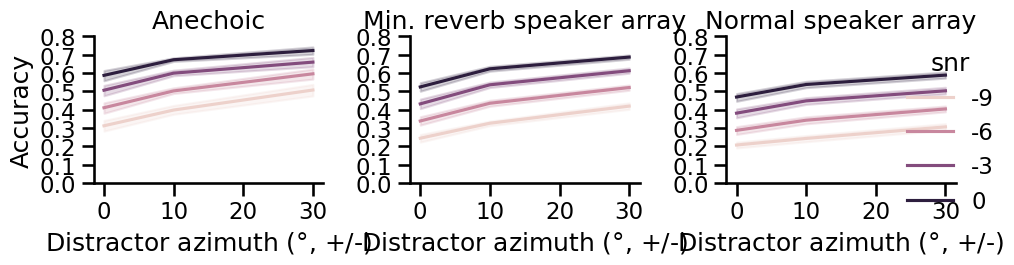

In [40]:
### Copy human plot above
to_plot = grouped_model_results[
    # (grouped_model_results.n_distractors == 2)
                        #   & (grouped_model_results.room_str == 'Normal speaker array')
                        #   & (grouped_model_results.model == 'word_task_half_co_loc_v07')
                          (grouped_model_results.distractor_azim.isin([0, -10, -30])) 
                          & (grouped_model_results.snr.isin([0, -3, -6, -9]))]

to_plot.distractor_azim = to_plot.distractor_azim.abs()
g = sns.relplot(data=to_plot,
                x='distractor_azim', y='accuracy_mean', hue="snr",
                kind='line', legend='full', 
                facet_kws={"sharey":False, "sharex":False},
                # col='n_distractors', 
                col='room_str',
                # style='test_set',
                # palette=palette, 
                height=3, aspect=1)

# plt.title('Model')
g.set_titles("{col_name}")
g.set(yticks = np.arange(0, 0.81, .1), xticks=np.arange(0, 31, 10))
# plt.ylim(0,0.8)
g.set_axis_labels("Distractor azimuth ($\degree$, +/-)", "Accuracy")
# set titles 
# g.set_titles("Target elevation: {row_name}\n{col_name}")
plt.tight_layout()

/tmp/ipykernel_586471/3769347842.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot.distractor_azim = to_plot.distractor_azim.abs()


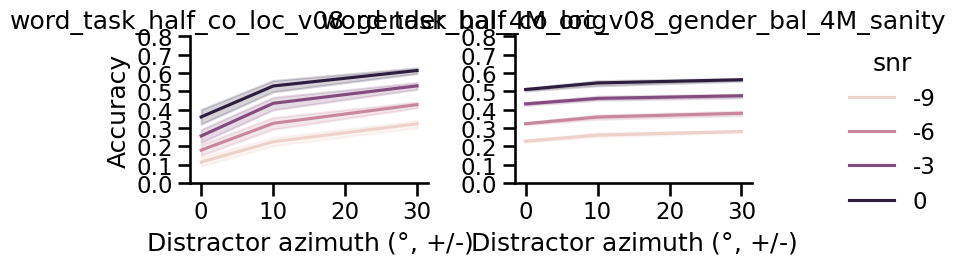

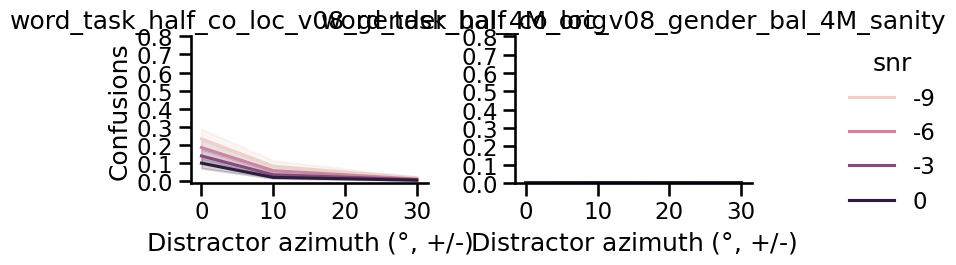

In [41]:
### Copy human plot above
to_plot = grouped_model_results[(grouped_model_results.n_distractors == 2)
                          & (grouped_model_results.room_str == 'Normal speaker array')
                        #   & (grouped_model_results.model == 'word_task_half_co_loc_v07')
                          & (grouped_model_results.distractor_azim.isin([0, -10, -30])) 
                          & (grouped_model_results.test_set == 'all_stim') 
                          & (grouped_model_results.snr.isin([0, -3, -6, -9]))]

to_plot.distractor_azim = to_plot.distractor_azim.abs()
g = sns.relplot(data=to_plot,
                x='distractor_azim', y='accuracy_mean', hue="snr",
                kind='line', legend='full', 
                facet_kws={"sharey":False, "sharex":False},
                col='model', 
                # palette=palette, 
                height=3, aspect=1)

# plt.title('Model')
g.set_titles("{col_name}")
g.set(yticks = np.arange(0, 0.81, .1), xticks=np.arange(0, 31, 10))
# plt.ylim(0,0.8)
g.set_axis_labels("Distractor azimuth ($\degree$, +/-)", "Accuracy")
# set titles 
# g.set_titles("Target elevation: {row_name}\n{col_name}")
plt.tight_layout()
g = sns.relplot(data=to_plot,
                x='distractor_azim', y='confusions_mean', hue="snr",
                kind='line', legend='full', 
                facet_kws={"sharey":False, "sharex":False},
                col='model', 
                # palette=palette, 
                height=3, aspect=1)

# plt.title('Model')
g.set_titles("{col_name}")
g.set(yticks = np.arange(0, 0.81, .1), xticks=np.arange(0, 31, 10))
# plt.ylim(0,0.8)
g.set_axis_labels("Distractor azimuth ($\degree$, +/-)", "Confusions")
# set titles 
# g.set_titles("Target elevation: {row_name}\n{col_name}")
plt.tight_layout()

In [24]:
grouped_model_results[grouped_model_results.n_distractors == 2].distractor_elev.unique()

array([-20,   0,  20,  40])

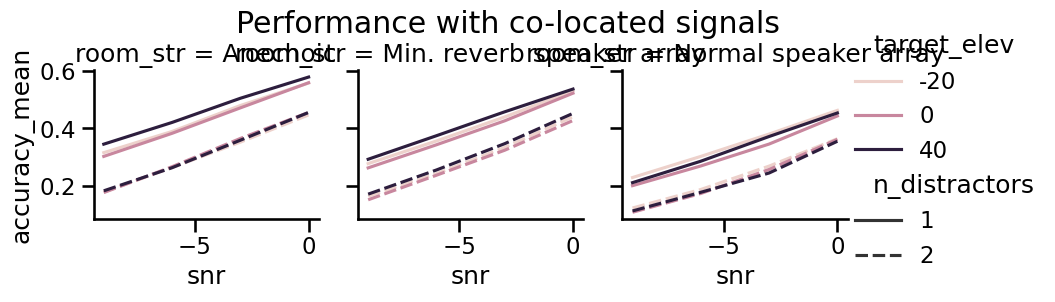

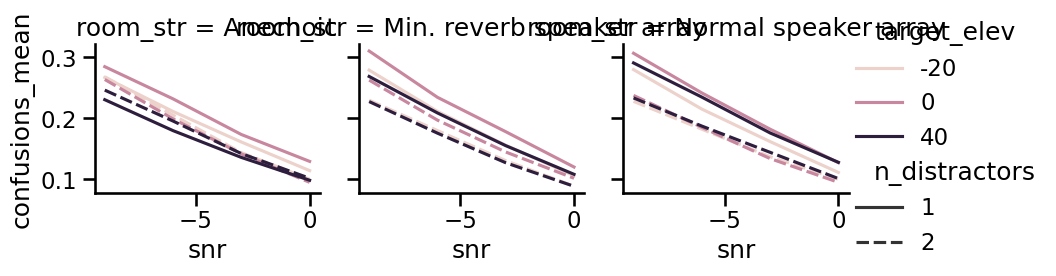

In [25]:
to_plot =  grouped_model_results[
                          #  (grouped_model_results.room_str == 'Normal speaker array')
                           (grouped_model_results.model == 'word_task_half_co_loc_v08_gender_bal_4M_orig')
                        #   & (grouped_model_results.target_elev.isin([-20, 40])) 
                          & (grouped_model_results.distractor_azim == 0)
                          & (grouped_model_results.snr.isin([0, -3, -6, -9]))
                          & (grouped_model_results.test_set == 'all_stim') 

                          ].groupby(['n_distractors','room_str', 'target_elev', 'snr']).agg({"accuracy_mean":'mean', 'confusions_mean':'mean'}).reset_index()

sns.relplot(data=to_plot, x='snr', y='accuracy_mean', kind='line',
            hue='target_elev',
            style='n_distractors',
            col='room_str',
            height=3, aspect=1)
plt.suptitle('Performance with co-located signals', y=1.02)

sns.relplot(data=to_plot, x='snr', y='confusions_mean', kind='line',
            hue='target_elev',
            style='n_distractors',
            col='room_str',
            height=3, aspect=1)


In [26]:
to_plot.room_str.unique()

array(['Anechoic', 'Min. reverb speaker array', 'Normal speaker array'],
      dtype=object)

/tmp/ipykernel_3609060/1433606102.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['elev_delta'] = (to_plot['target_elev'] - to_plot['distractor_elev']).abs()


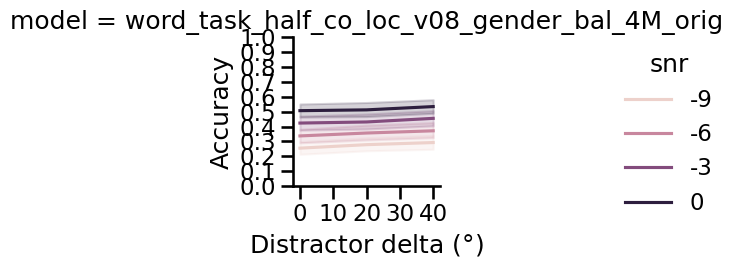

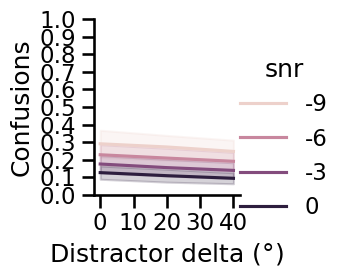

In [27]:
### Copy human plot above
to_plot = grouped_model_results[
                           (grouped_model_results.n_distractors == 1) 
                        #    (grouped_model_results.room_str == 'Normal speaker array')
                          # & (grouped_model_results.model == 'word_task_half_co_loc_v07')
                          & (grouped_model_results.target_elev.isin([-20, 40])) 
													&	(grouped_model_results.distractor_azim == 0) 

                          & (grouped_model_results.test_set == 'all_stim') 

                          & (grouped_model_results.snr.isin([0, -3, -6, -9]))]


# to_plot = results_df[results_df.n_distractors == 1]
to_plot['elev_delta'] = (to_plot['target_elev'] - to_plot['distractor_elev']).abs()

g = sns.relplot(data=to_plot,
                x='elev_delta', y='accuracy_mean', hue="snr",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                col='model', 
                # row='target_elev',
                # palette=palette, 
                # errorbar=('se', 2),
                height=3, aspect=1)
# plt.title('Humans (N=2)')
g.set(yticks=np.arange(0, 1.1, .1), xticks=np.arange(0, 41, 10))
# plt.ylim(0,0.8)
g.set_axis_labels("Distractor delta ($\degree$)", "Accuracy")
# g.set_titles("{col_name} {row_name}")


g = sns.relplot(data=to_plot,
                x='elev_delta', y='confusions_mean', hue="snr",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                # col='model', 
                # col='target_elev',
                # palette=palette, 
                # errorbar=('se', 2),
                height=3, aspect=1)
# plt.title('Humans (N=2)')
g.set(yticks=np.arange(0, 1.1, .1), xticks=np.arange(0, 41, 10))
# plt.ylim(0,0.8)
g.set_axis_labels("Distractor delta ($\degree$)", "Confusions")
# g.set_titles("{col_name}")


/tmp/ipykernel_3609060/4183547556.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['elev_delta'] = (to_plot['target_elev'] - to_plot['distractor_elev']).abs()


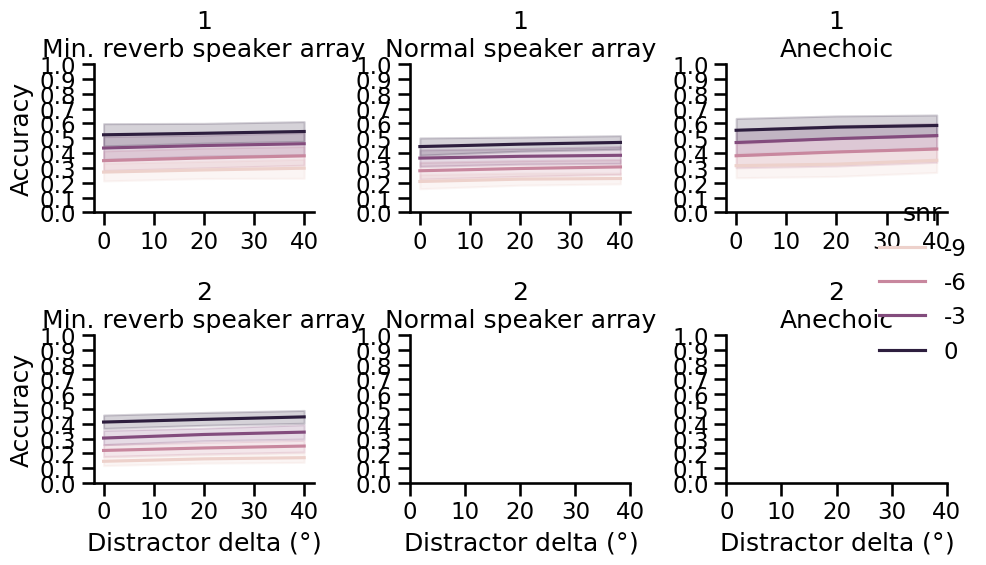

In [28]:
### Copy human plot above
to_plot = grouped_model_results[
    # (grouped_model_results.n_distractors == 1)
                        #   & (grouped_model_results.room_str == 'Anechoic')
                          # & (grouped_model_results.model == 'word_task_half_co_loc_v07')
                           (grouped_model_results.target_elev.isin([-20, 40])) 
                          & (grouped_model_results.distractor_azim == 0) 
                          & (grouped_model_results.snr.isin([0, -3, -6, -9]))]


# to_plot = results_df[results_df.n_distractors == 1]
to_plot['elev_delta'] = (to_plot['target_elev'] - to_plot['distractor_elev']).abs()

g = sns.relplot(data=to_plot,
                x='elev_delta', y='accuracy_mean', hue="snr",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                # row='model', 
                col='room_str',
                row='n_distractors',
                # palette=palette, 
                # errorbar=('se', 2),
                height=3, aspect=1)
# plt.title('Humans (N=2)')
g.set(yticks=np.arange(0, 1.1, .1), xticks=np.arange(0, 41, 10))
# plt.ylim(0,0.8)
g.set_axis_labels("Distractor delta ($\degree$)", "Accuracy")


# set titles 
g.set_titles("{row_name}\n{col_name}")
# g = sns.relplot(data=to_plot,
#                 x='elev_delta', y='accuracy_mean', hue="snr",
#                 kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
#                 col='target_elev', 
#                 # palette=palette, 
#                 # errorbar=('se', 2),
#                 height=3, aspect=1)
# # plt.title('Humans (N=2)')
# # g.set( xticks=np.arange(0, 31, 10))
# # plt.ylim(0,0.8)
# g.set_axis_labels("Distractor delta ($\degree$)", "Accuracy")
# # set titles 

# move legend up 
plt.tight_layout()


In [70]:
### Make threshold dataframe 
thresholds = []
for (model, room, target_azim, target_elev, dist_azim, dist_elev, n_dist, dist_type), group in grouped_model_results.groupby(['model', 'room_str', 'target_azim', 'target_elev', 'distractor_azim', 'distractor_elev', 'n_distractors', 'distractor_type']): #, 'gender_cond']):
    try:
        thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.accuracy_mean.values, bounds_from_data=True)
        thresholds.append({'model':model, 'room_ix':room, 'target_azim':target_azim, 'target_elev':target_elev, 
                        'dist_azim':dist_azim, 'dist_elev':dist_elev, 'n_distractors':n_dist, 'dist_type':dist_type, 'threshold':thresh}) #  'gender_cond':gend_cond,
    except Exception as e:
        print(f"Failed to estimate threshold for {model} {room} {target_azim} {target_elev} {dist_azim} {dist_elev} {n_dist} {dist_type}")
        print(e)
        continue
    
thresh_df = pd.DataFrame(thresholds)


Failed to estimate threshold for word_task_half_co_loc_v08_gender_bal_4M_sanity Min. reverb speaker array 0 -20 -180 -20 2 white_noise
Each lower bound must be strictly less than each upper bound.
Failed to estimate threshold for word_task_half_co_loc_v08_gender_bal_4M_sanity Min. reverb speaker array 0 -20 -150 -20 2 white_noise
Each lower bound must be strictly less than each upper bound.
Failed to estimate threshold for word_task_half_co_loc_v08_gender_bal_4M_sanity Min. reverb speaker array 0 -20 -120 -20 2 white_noise
Each lower bound must be strictly less than each upper bound.
Failed to estimate threshold for word_task_half_co_loc_v08_gender_bal_4M_sanity Min. reverb speaker array 0 -20 -90 -20 2 white_noise
Each lower bound must be strictly less than each upper bound.
Failed to estimate threshold for word_task_half_co_loc_v08_gender_bal_4M_sanity Min. reverb speaker array 0 0 -10 0 2 white_noise
Each lower bound must be strictly less than each upper bound.
Failed to estimate th

In [78]:
thresh_df

,model,room_ix,target_azim,target_elev,dist_azim,dist_elev,n_distractors,dist_type,threshold
0,word_task_half_co_loc_v08_gender_bal_4M_orig,Anechoic,0,-20,-180,-20,2,speech,-2.586560
1,word_task_half_co_loc_v08_gender_bal_4M_orig,Anechoic,0,-20,-150,-20,2,speech,-11.260735
2,word_task_half_co_loc_v08_gender_bal_4M_orig,Anechoic,0,-20,-120,-20,2,speech,-13.023613
3,word_task_half_co_loc_v08_gender_bal_4M_orig,Anechoic,0,-20,-90,-20,2,speech,-12.643681
4,word_task_half_co_loc_v08_gender_bal_4M_orig,Anechoic,0,-20,-60,-20,2,speech,-12.679692
...,...,...,...,...,...,...,...,...,...
179,word_task_half_co_loc_v08_gender_bal_4M_sanity,Min. reverb speaker array,0,40,0,0,2,white_noise,-7.981337
180,word_task_half_co_loc_v08_gender_bal_4M_sanity,Min. reverb speaker array,0,40,0,20,2,speech,-0.056112
181,word_task_half_co_loc_v08_gender_bal_4M_sanity,Min. reverb speaker array,0,40,0,20,2,white_noise,-3.000000
182,word_task_half_co_loc_v08_gender_bal_4M_sanity,Min. reverb speaker array,0,40,0,40,2,speech,1.487506


/tmp/ipykernel_163568/2273895222.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['distractor_azim'] = to_plot.dist_azim.abs()


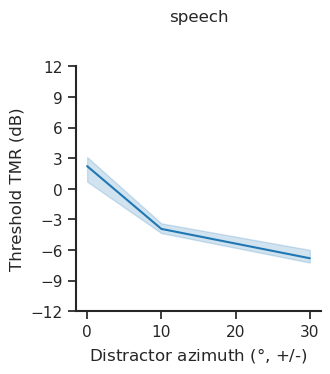

In [112]:
# plot thresholds for each model 



### Copy human plot above
to_plot = thresh_df[(thresh_df.n_distractors == 2)
                          & (thresh_df.room_ix == 'Normal speaker array')
                          & (thresh_df.model == 'word_task_half_co_loc_v08_gender_bal_4M_orig')
                          & (thresh_df.dist_azim.isin([0, -10, -30])) 
                          ]


to_plot['distractor_azim'] = to_plot.dist_azim.abs()

g = sns.relplot(data=to_plot, x='distractor_azim', y='threshold', kind='line',
                # hue='gender_cond',
                col='dist_type',
                # style='room_ix',
                height=3.5, aspect=1)
# update legend 
g.set_titles("{col_name}", size=12, y=1.15)

g.set_axis_labels("Distractor azimuth ($\degree$, +/-)", "Threshold TMR (dB)")
g.set(yticks=np.arange(-12,13,3) , xticks=np.arange(0, 31, 10))
ratio = 1 
for ax in g.axes.flat:
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1.5)
# g.legend.set_title('')

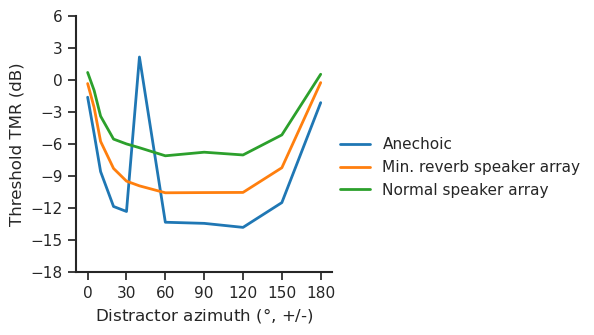

In [133]:
# plot thresholds for each model 
sns.set_style('ticks')
sns.set_context('notebook', rc={"lines.linewidth": 2})
to_plot = thresh_df[(thresh_df.target_elev == thresh_df.dist_elev)
                    & (thresh_df.model == 'word_task_half_co_loc_v08_gender_bal_4M_orig')
                    # & (thresh_df.room_ix.isin([0,5,9,10]))
                    & (thresh_df.target_elev == 0)
                    & (thresh_df.n_distractors == 2)
                    ].copy()
to_plot['distractor_azim'] = to_plot.dist_azim.abs()
g = sns.relplot(data=to_plot, x='distractor_azim', y='threshold', kind='line',
                # hue='gender_cond',
                # col='model',
                hue='room_ix',
                height=4, aspect=1)
# update legend 
g.set_titles("{col_name}", size=12, y=1.1)

g.set_axis_labels("Distractor azimuth ($\degree$, +/-)", "Threshold TMR (dB)")
g.set(yticks=np.arange(-18,7,3) , xticks=np.arange(0, 181, 30))
ratio = 1 
for ax in g.axes.flat:
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1.5)
g.legend.set_title('')

/tmp/ipykernel_163568/874016877.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['dist_elev_delta'] = (to_plot.target_elev - to_plot.dist_elev).abs()


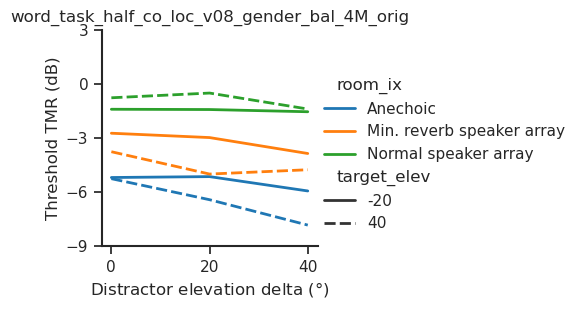

In [132]:
# plot thresholds for each model 

to_plot = thresh_df[(thresh_df.target_azim == thresh_df.dist_azim)
                    & (thresh_df.model == 'word_task_half_co_loc_v08_gender_bal_4M_orig')
                    & (thresh_df.target_elev.isin([-20, 40]))
                    & (thresh_df.target_azim == 0)
                    & (thresh_df.n_distractors == 1)
                    & (thresh_df.dist_type == 'speech')

                    ]
to_plot['dist_elev_delta'] = (to_plot.target_elev - to_plot.dist_elev).abs()
g = sns.relplot(data=to_plot, x='dist_elev_delta', y='threshold', kind='line',
                # hue='gender_cond',
                col='model',
                style='target_elev',
                hue='room_ix',
                facet_kws={"sharey":False, "sharex":False},
                height=3.5, aspect=1)
# update legend 

g.set_axis_labels("Distractor elevation delta ($\degree$)", "Threshold TMR (dB)")
g.set(yticks=np.arange(-9, 4,3), xticks=np.arange(0, 41, 20))
g.set_titles("{col_name}")

ratio = 1 
for ax in g.axes.flat:
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1.5)
# g.legend.set_title('')
# plt.tight_layout()